<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

drop_cols = ["SEQN", "LBXGH", "diabetes_label", "diabetes_binary"]
X = dataset.drop(columns = drop_cols)
y = dataset["diabetes_label"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [3]:
tier1_cols =[
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", # demographics
    "BMXBMI", "BMXWAIST", # anthropometric
    "BPXSY_mean", "BPXDI_mean" # blood pressure
    ]
tier2_cols = tier1_cols +[
    "LBXTC", "LBXTR", # lipids
    "LBXSCR", # creatinine
    "LBXSATSI", "LBXSASSI", # liver enzymes (ALT, AST)
    "LBXSUA" # uric acid
]
tier3_cols = tier2_cols + [
    "LBXSTP", "LBXSAL", "LBXSCA", # total protein, albumin, calcium
    "LBXSPH", "LBXSNASI", "LBXSKSI", # phosphorus, sodium, potassium
    "LBXSGB", "LBXSBU", "LBXSC3SI"# globulin, BUN, bicarbonate
]
tiers = {
    "Tier 1 (Demographic + Vitals)": tier1_cols,
    "Tier 2 (Liver Measurements)": tier2_cols,
    "Tier 3 (Full Panel)": tier3_cols
}

In [4]:
class Node:
  def __init__(self, feature = None, threshold = None, left = None, right = None, *, value = None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.value = value

  def is_leaf(self):
      return self.value is not None

class DecisionTree:
  def __init__(self, max_depth= None, min_samples_split= 2):
    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
    self.root = None

  def _entropy(self, y):
    if len(y) == 0:
      return 0
      classes, counts = np.unique(y_return_counts = True)
      probs = counts / len(y)
      return -np.sum(probs * np.log2(probs + 1e-9))

  def best_split(self, x, y):
    best_feature = None
    best_threshold = None
    best_loss = float("inf")

    n_samples, n_features = x.shape
    for feature in range(n_features):
      sorted_indices = np.argsort(x[:, feature])

      x_feature_sorted = x[sorted_indices, feature]
      y_sorted = y[sorted_indices]

      left_count = 0
      right_count = n_samples

      left_sum = 0.0
      right_sum = np.sum(y_sorted)

      left_sq_sum = 0.0
      right_sq_sum = np.sum(y_sorted**2)

      for i in range (1, n_samples):
        yi = y_sorted[i -1]
        left_count += 1
        right_count -= 1
        left_sum += yi
        right_sum -= yi
        left_sq_sum += yi**2
        right_sq_sum -= yi**2

        if x_feature_sorted[i] == x_feature_sorted[i-1]:
          continue

        if left_count == 0 or right_count == 0:
            continue

        left_mse = (left_sq_sum/left_count) - (left_sum/left_count)**2
        right_mse = (right_sq_sum/right_count) - (right_sum/right_count)**2

        loss = left_count * left_mse + right_count * right_mse

        if loss < best_loss:
          best_loss = loss
          best_feature = feature
          best_threshold = (x_feature_sorted[i] + x_feature_sorted[i-1]) / 2

    return best_feature, best_threshold

  def _build(self, x, y, depth):
    if len(y) < self.min_samples_split:
        return Node(value=np.mean(y))
    if self.max_depth is not None and depth >= self.max_depth:
        return Node(value=np.mean(y))

    feature, threshold = self.best_split(x, y)

    if feature is None:
        return Node(value=np.mean(y))

    left_mask  = x[:, feature] <= threshold
    right_mask = ~left_mask

    parent_var = np.var(y) * len(y)
    left_var   = np.var(y[left_mask])  * left_mask.sum()  if left_mask.sum()  > 0 else 0
    right_var  = np.var(y[right_mask]) * right_mask.sum() if right_mask.sum() > 0 else 0
    reduction  = (parent_var - left_var - right_var) / len(y)
    fname      = self._feature_names[feature]
    self.feature_importance[fname] = self.feature_importance.get(fname, 0.0) + reduction

    left  = self._build(x[left_mask],  y[left_mask],  depth + 1)
    right = self._build(x[right_mask], y[right_mask], depth + 1)
    return Node(feature, threshold, left, right)

  def build_tree(self, x, y, feature_names):
    self._feature_names     = feature_names
    self.feature_importance = {name: 0.0 for name in feature_names}
    self.root               = self._build(x, y, 0)

  def _predict_one(self, x_sample, node):
    if node.value is not None:
      return node.value
    if x_sample[node.feature] <= node.threshold:
      return self._predict_one(x_sample, node.left)
    else:
      return self._predict_one(x_sample, node.right)

  def predict(self, X_test):
    return np.array([self._predict_one(i, self.root) for i in X_test])

In [5]:
best_depth = None
best_min_split = None
best_mse = float('inf')

print(f"{'Max Depth':<12} {'Min Split':<12} {'Train MSE':>10} {'Test MSE':>10}")
print("-" * 48)

x_train_np = x_train.values
x_test_np = x_test.values
y_train_np = y_train.values
y_test_np = y_test.values
all_cols   = list(x_train.columns)

for depth in [3, 5, 7, 10, None]:
    for min_split in [2, 5, 10, 20, 30]:
        tree = DecisionTree(max_depth=depth, min_samples_split=min_split)
        tree.build_tree(x_train_np, y_train_np, all_cols)
        train_mse = np.mean((tree.predict(x_train_np) - y_train_np) ** 2)
        test_mse  = np.mean((tree.predict(x_test_np)  - y_test_np)  ** 2)
        print(f"{str(depth):<12} {min_split:<12} {train_mse:>10.4f} {test_mse:>10.4f}")
        if test_mse < best_mse:
            best_mse       = test_mse
            best_depth     = depth
            best_min_split = min_split

print(f"\n Best Depth: {best_depth}   Best Split:{best_min_split}   Best MSE: {best_mse:.2f}")

Max Depth    Min Split     Train MSE   Test MSE
------------------------------------------------
3            2                0.3705     0.3649
3            5                0.3705     0.3649
3            10               0.3705     0.3649
3            20               0.3705     0.3649
3            30               0.3705     0.3649
5            2                0.3366     0.3639
5            5                0.3366     0.3639
5            10               0.3366     0.3639
5            20               0.3377     0.3628
5            30               0.3383     0.3625
7            2                0.2874     0.3931
7            5                0.2883     0.3939
7            10               0.2924     0.3922
7            20               0.2957     0.3833
7            30               0.3016     0.3766
10           2                0.1827     0.4787
10           5                0.1882     0.4746
10           10               0.2051     0.4698
10           20               0.2251   

In [6]:
class RandomForest:
  def __init__(self, n_trees=100, max_depth=3, min_samples_split=5,
                 n_features=None, sample_ratio=0.8, random_seed=42):
        self.n_trees           = n_trees
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.n_features        = n_features
        self.sample_ratio      = sample_ratio
        self.random_seed       = random_seed
        self.trees             = []
        self.tree_features     = []

  def build_forest (self, x, y, feature_names):
    n_samples, n_total_features = x.shape
    n_feat = self.n_features or max(1, int(np.floor(np.sqrt(n_total_features))))
    n_sub = max(1, int(self.sample_ratio * n_samples))

    rng = np.random.default_rng(self.random_seed)
    self.trees = []
    self.tree_features = []

    for i in range(self.n_trees):
      row_idx = rng.choice(n_samples, size= n_sub, replace = True)
      feature_idx = rng.choice(n_total_features, size= n_feat, replace = False)
      x_sub = x[row_idx][:, feature_idx]
      y_sub = y[row_idx]
      tree = DecisionTree(max_depth=self.max_depth, min_samples_split= self.min_samples_split)
      sub_names = [feature_names[i] for i in feature_idx]
      tree.build_tree(x_sub, y_sub, sub_names)
      self.trees.append(tree)
      self.tree_features.append(feature_idx)

  def predict(self, x):
    all_preds = np.array ([
        tree.predict(x[:, feature_idx])
        for tree, feature_idx in zip(self.trees, self.tree_features)
    ])
    return np.mean(all_preds, axis = 0)

In [7]:
best_rf_mse = float('inf')
best_n_trees = None
best_n_feat = None

print(f"{'n feat':<8} {'n trees':<10} {'Test MSE':>10}")
print("-" * 30)
x_train_rf_np = x_train.values
y_train_rf_np = y_train.values
x_test_rf_np  = x_test.values
y_test_rf_np  = y_test.values
for n_feat in [4, 5, 6, 7]:
    for n_trees in [50, 100, 200]:
        rf = RandomForest(n_trees=n_trees, max_depth=3, min_samples_split=2,
                          n_features=n_feat, sample_ratio=0.8, random_seed=42)
        rf.build_forest(x_train_rf_np, y_train_rf_np, all_cols)
        test_mse = np.mean((rf.predict(x_test_rf_np) - y_test_rf_np) ** 2)
        print(f"{n_feat:<8} {n_trees:<10} {test_mse:>10.2f}")
        if test_mse < best_rf_mse:
            best_rf_mse = test_mse
            best_n_trees = n_trees
            best_n_feat = n_feat

print(f"\n Single Tree - Test MSE: {best_mse:7.2f}")
print(f"Random Forest - Test MSE: {best_rf_mse:.2f}")

n feat   n trees      Test MSE
------------------------------
4        50               0.38
4        100              0.38
4        200              0.38
5        50               0.38
5        100              0.38
5        200              0.38
6        50               0.37
6        100              0.37
6        200              0.37
7        50               0.36
7        100              0.36
7        200              0.37

 Single Tree - Test MSE:    0.36
Random Forest - Test MSE: 0.36


In [8]:
def predict_one(x, node):
  if node.isleaf():
    return node.value, node.probs
  if x[node.feature] <= node.threshold:
    return predict(x, node.left)
  else:
    return predict(x, node.right)

def predict(X, tree):
  preds = []
  probs = []
  for x in X:
    pred, prob = predict_one(x, tree)
    preds.append(pred)
    probs.append(prob)
  return np.array(preds), np.array(probs)

In [9]:
def confusion_matrix_counts (y_true, y_pred):
  TP = np.sum((y_true == 1) & (y_pred ==1))
  FP = np.sum((y_true == 0) & (y_pred ==1))
  TN = np.sum((y_true == 0) & (y_pred ==0))
  FN = np.sum((y_true == 1) & (y_pred ==0))
  return TP, FP, TN, FN

def f1_classwise(y_true, y_pred, n_classes):
  results ={}
  for c in range(n_classes):
    y_true_bin = (y_true == c).astype(int)
    y_pred_bin = (y_pred == c).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true_bin, y_pred_bin)
    precision = TP / (TP + FP+ 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall)
    results [c] = {"f1": f1, "precision": precision, "recall": recall}
  return results


In [10]:
def auroc(y_true, y_prob):
  thresholds = np.linspace(0,1, 1000)
  tprs, fprs = [], []
  for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
    tprs.append(TP/(TP+FN +1e-9))
    fprs.append(FP/(FP+TN +1e-9))
  fprs, tprs = zip(*sorted(zip(fprs, tprs)))
  fprs, tprs = np.array(fprs), np.array(tprs)
  auroc = np.trapezoid(tprs, fprs)
  return auroc, fprs, tprs

In [11]:
def auprc(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1000)
    precisions, recalls = [], []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
        precisions.append(TP / (TP + FP + 1e-9))
        recalls.append(TP / (TP + FN + 1e-9))

    recalls = np.array(recalls)
    precisions = np.array(precisions)

    sorted_idx = np.argsort(recalls)
    recalls = recalls[sorted_idx]
    precisions = precisions[sorted_idx]

    auprc_val = np.trapezoid(precisions, recalls)
    return auprc_val, recalls, precisions

In [12]:
n_classes = 3
tier_results = {}
tier_trees = {}
tier_importance = {}

for tier_name, cols in tiers.items():
  print(f"\n ------- {tier_name}-----------")
  X_train_tier = x_train[cols]
  X_test_tier = x_test[cols].values
  Y_train_tier = y_train.values
  Y_test_tier = y_test.values

  dt_model = DecisionTree(max_depth=5, min_samples_split=10)
  dt_model.build_tree(X_train_tier.values, Y_train_tier, cols)
  tier_trees[tier_name] = dt_model
  tier_importance[tier_name] = dt_model.feature_importance
  y_pred_raw = dt_model.predict(X_test_tier)
  y_pred = np.clip(np.round(y_pred_raw).astype(int), 0, n_classes - 1)
  y_probs = np.zeros((len(y_pred), n_classes))
  y_probs[np.arange(len(y_pred)), y_pred] = 1.0

  f1_scores  = f1_classwise(Y_test_tier, y_pred, n_classes)

  tier_results[tier_name] = {"f1":{}, "auroc":{}, "auprc":{}}
  auroc_vals = []
  for c in range(n_classes):
    y_true_bin = (Y_test_tier == c).astype(int)
    y_prob_c = y_probs[:,c]
    auroc_val, fprs, tprs = auroc(y_true_bin, y_prob_c)
    auprc_val, precision, recall = auprc(y_true_bin, y_prob_c)
    f1_val = f1_scores[c]["f1"]
    tier_results[tier_name]["f1"][c]  = f1_val
    tier_results[tier_name]["auroc"][c] = auroc_val
    tier_results[tier_name]["auprc"][c]= auprc_val
    auroc_vals.append(auroc_val)
    print(f"Class {c} | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")
macro_auroc = np.mean(auroc_vals)
print(f"Macro AUROC: {macro_auroc:.4f}")


 ------- Tier 1 (Demographic + Vitals)-----------
Class 0 | F1: 0.7410  AUROC: 0.6652  AUPRC: 0.2459
Class 1 | F1: 0.5249  AUROC: 0.5100  AUPRC: 0.0859
Class 2 | F1: 0.0138  AUROC: 0.4990  AUPRC: 0.1001

 ------- Tier 2 (Liver Measurements)-----------
Class 0 | F1: 0.7564  AUROC: 0.6607  AUPRC: 0.2233
Class 1 | F1: 0.5322  AUROC: 0.5302  AUPRC: 0.0917
Class 2 | F1: 0.0563  AUROC: 0.5130  AUPRC: 0.2963

 ------- Tier 3 (Full Panel)-----------
Class 0 | F1: 0.7623  AUROC: 0.6506  AUPRC: 0.2103
Class 1 | F1: 0.5267  AUROC: 0.5424  AUPRC: 0.1050
Class 2 | F1: 0.1274  AUROC: 0.5308  AUPRC: 0.2525
Macro AUROC: 0.5746


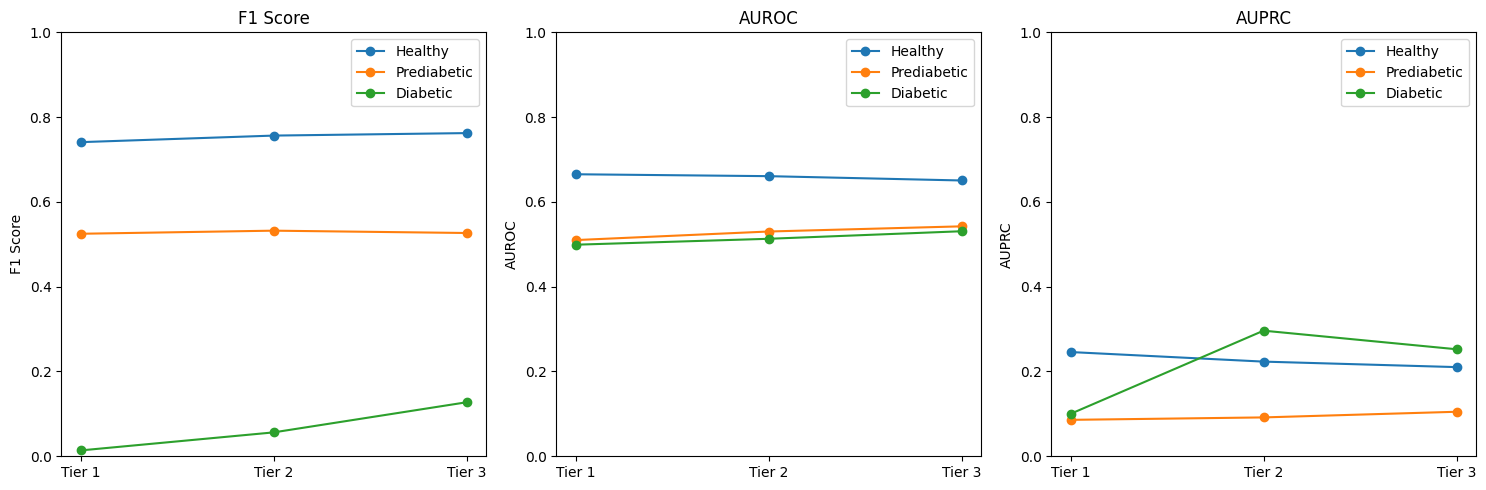

In [13]:
CLASS_NAMES = {0: 'Healthy', 1: 'Prediabetic', 2: 'Diabetic'}
tier_names = list(tiers.keys())
x_labels = ['Tier 1', 'Tier 2', 'Tier 3']

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, metric, label in zip(axes, ['f1', 'auroc', 'auprc'], ['F1 Score', 'AUROC', 'AUPRC']):
  for c, cname in CLASS_NAMES.items():
    scores = [tier_results[t][metric][c] for t in tier_names]
    ax.plot(x_labels, scores, marker = 'o', label = cname)
  ax.set_title(label)
  ax.set_ylabel(label)
  ax.legend()
  ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

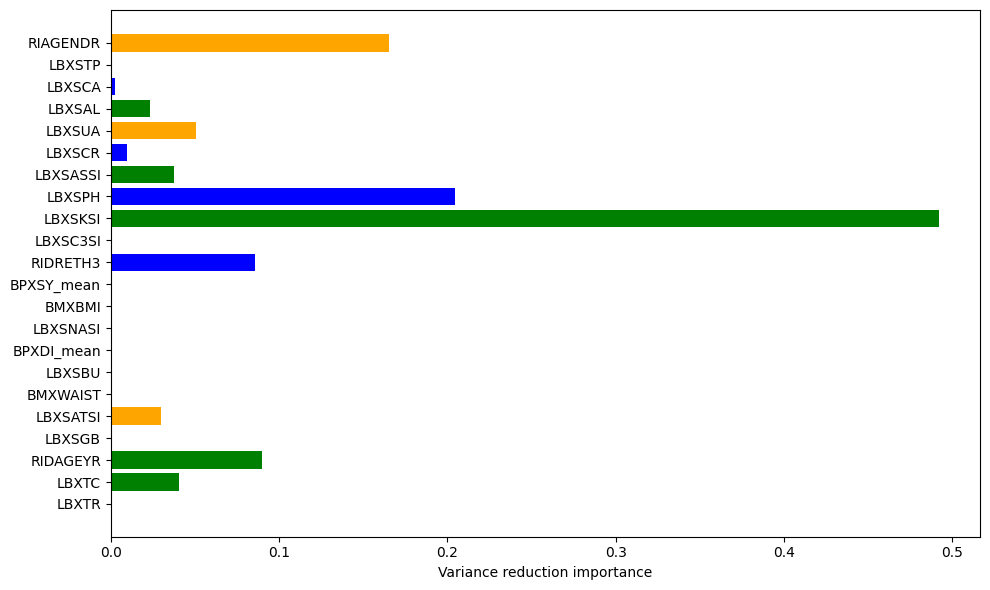

In [14]:
importance = tier_importance['Tier 3 (Full Panel)']
feat_names = list(importance.keys())
feat_values = np.array(list(importance.values()))
order = np.argsort(feat_values)[::-1]
feat_names_sorted = [feat_names[i] for i in order]
feat_values_sorted = feat_values[order]

tier1_set = set(tier1_cols)
tier2_set = set(tier2_cols) - tier1_set

tier1_set = set(tier1_cols)
tier2_set = set(tier2_cols) - tier1_set
colors = []
for name in feat_names_sorted:
  if name in tier1_set:
    colors.append('blue')
  elif name in tier2_set:
    colors.append('orange')
  else:
    colors.append('green')

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(feat_names_sorted, feat_values[::-1], color = colors[::-1])
ax.set_xlabel('Variance reduction importance')

plt.tight_layout()
plt.show()

In [15]:
def print_tree(node, feature_names,depth=0, max_print_depth = 3, prefix = ''):
  if depth >= max_print_depth:
    return
  indent = '  '*depth
  if node.is_leaf():
    print(f'{indent}{prefix}Leaf->{CLASS_NAMES.get(node.value, str(node.value))}')
  else :
    fname = feature_names[node.feature]
    print(f'{indent}{prefix}{fname} <= {node.threshold}')
    print_tree(node.left, feature_names, depth + 1, max_print_depth, 'LEFT')
    print_tree(node.right, feature_names, depth+1, max_print_depth, 'RIGHT ')

print('Decision Tree Tier 1 (first 3 levels)')
t1_tree = tier_trees['Tier 1 (Demographic + Vitals)']
print_tree(t1_tree.root, feature_names=tier1_cols, max_print_depth=3)

Decision Tree Tier 1 (first 3 levels)
RIDAGEYR <= 45.5
  LEFTBMXWAIST <= 104.75
    LEFTRIDAGEYR <= 31.5
    RIGHT RIDAGEYR <= 35.5
  RIGHT BMXWAIST <= 111.65
    LEFTRIDAGEYR <= 62.5
    RIGHT BPXDI_mean <= 74.5


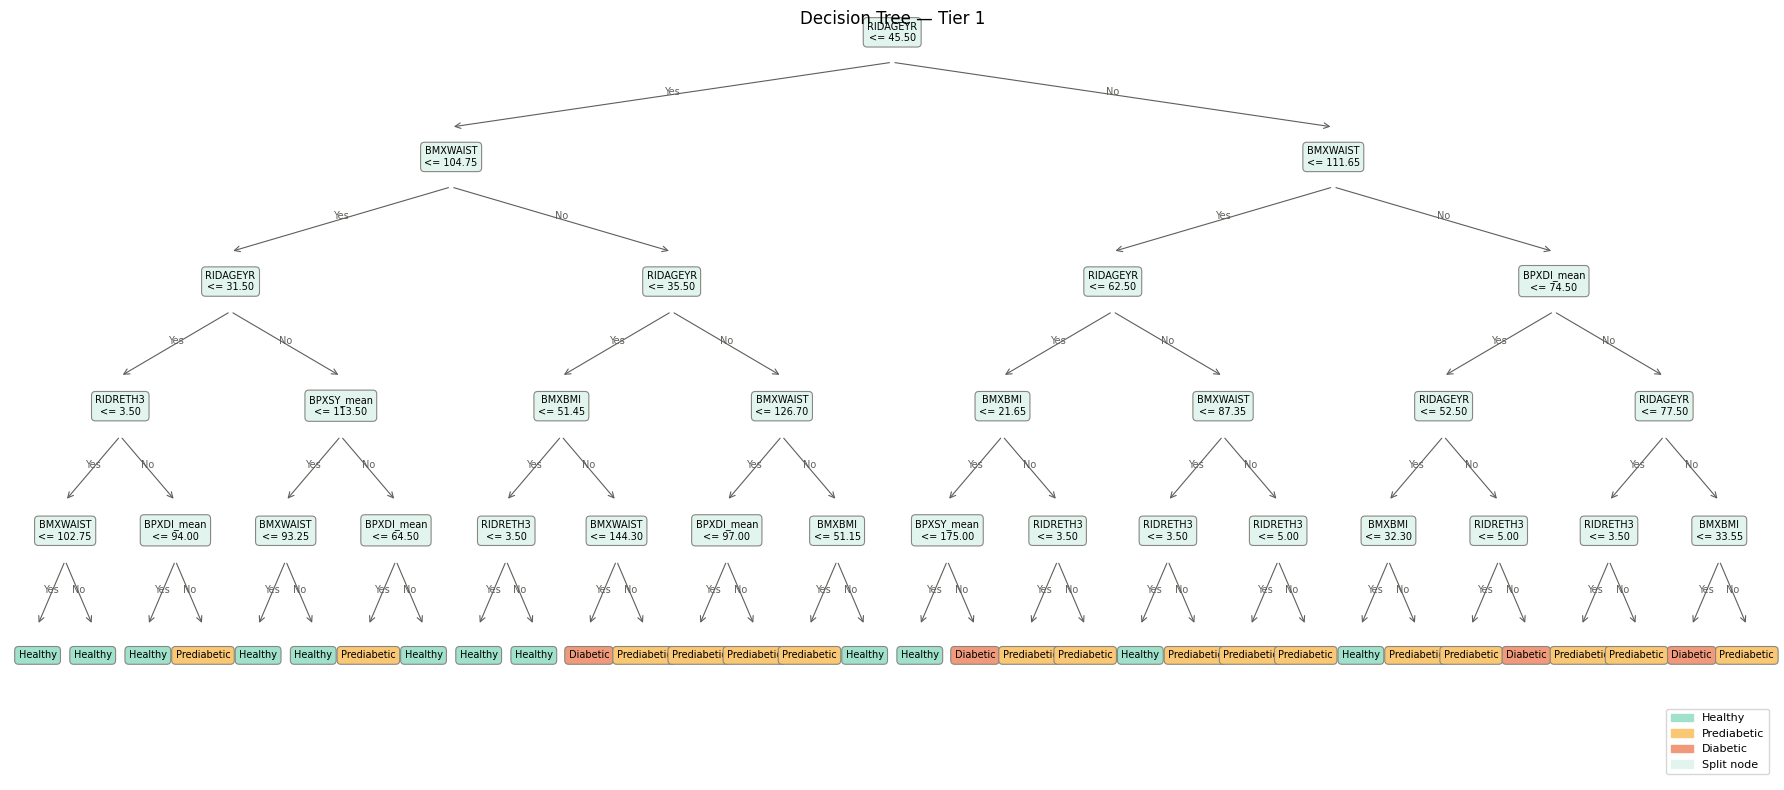

In [16]:
CLASS_NAMES = {0: 'Healthy', 1: 'Prediabetic', 2: 'Diabetic'}

def plot_tree(tree, feature_names, max_depth=3):
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.axis('off')

    NODE_COLORS = {'Healthy': '#9FE1CB', 'Prediabetic': '#FAC775', 'Diabetic': '#F0997B'}
    SPLIT_COLOR = '#E1F5EE'
    node_pos = {}

    def assign_positions(node, depth, x0, x1):
        x = (x0 + x1) / 2
        y = 1 - depth / (max_depth + 1)
        node_pos[id(node)] = (x, y)
        if not node.is_leaf() and depth < max_depth:
            mid = (x0 + x1) / 2
            assign_positions(node.left,  depth+1, x0,  mid)
            assign_positions(node.right, depth+1, mid, x1)

    assign_positions(tree.root, 0, 0, 1)

    def draw(node, depth):
        if id(node) not in node_pos:
            return
        x, y = node_pos[id(node)]

        if node.is_leaf():
            cname = CLASS_NAMES.get(int(round(node.value)), 'Unknown')
            label = cname
            color = NODE_COLORS.get(cname, '#cccccc')
        else:
            label = f'{feature_names[node.feature]}\n<= {node.threshold:.2f}'
            color = SPLIT_COLOR

        ax.text(x, y, label, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          edgecolor='#888780', linewidth=0.8))

        if not node.is_leaf() and depth < max_depth:
            for child, edge_label in [(node.left, 'Yes'), (node.right, 'No')]:
                if id(child) in node_pos:
                    cx, cy = node_pos[id(child)]
                    ax.annotate('', xy=(cx, cy+0.04), xytext=(x, y-0.04),
                                arrowprops=dict(arrowstyle='->', color='#5F5E5A', lw=0.8))
                    ax.text((x+cx)/2, (y+cy)/2, edge_label, fontsize=7,
                            ha='center', color='#5F5E5A')
            draw(node.left,  depth+1)
            draw(node.right, depth+1)

    draw(tree.root, 0)

    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color='#9FE1CB', label='Healthy'),
        mpatches.Patch(color='#FAC775', label='Prediabetic'),
        mpatches.Patch(color='#F0997B', label='Diabetic'),
        mpatches.Patch(color='#E1F5EE', label='Split node'),
    ]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
    plt.title('Decision Tree — Tier 1', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_tree(tier_trees['Tier 1 (Demographic + Vitals)'], feature_names=tier1_cols, max_depth=5)